# 03 · Baselines

What a complex model has to beat, and by how much. Rule 5 of `CLAUDE.md` asks for that number
explicitly: a model that cannot show it is not justified.

> **Everything here is scored on validation (2018-04 .. 2018-05), never on test.** Model choice
> happens on validation; the test block is read once, at the end of S3, with every choice
> already frozen. Its base rate is 10.19% against validation's 11.86%, so the two are not
> interchangeable either.

Four baselines, at both decision moments:

| Baseline | What it is |
|---|---|
| `constant` | One number for everybody: the training base rate. The floor - its PR-AUC is the prevalence by construction |
| `single feature` | The strongest variable used raw as the score. The rule an analyst writes with no model at all |
| `logistic` | Logistic regression on all the features of that moment |
| `logistic binned` | The same, with every numeric feature cut into deciles |

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_recall_curve

from src import config, evaluate, features, train

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, BAND = "#0b0b0b", "#52514e", "#e8e8e6"
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "savefig.dpi": 200,
        "font.size": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK,
        "text.color": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "grid.color": BAND,
        "grid.linewidth": 0.8,
    }
)

matrix = features.load_features()
blocks = matrix.groupby("split", observed=True).agg(orders=("y", "size"), prevalence=("y", "mean"))
print(blocks.reindex(config.SPLIT_ORDER).to_string(float_format=lambda v: f"{v:.4f}"))

       orders  prevalence
split                    
train   64360      0.1470
val     13612      0.1186
test    18664      0.1019


## 1 · The table

Everything is fitted on training and scored on validation. `recall@10%` is the share of all
negative reviews caught inside the 10% of orders the model ranks highest, and `lift@10%` is how
many times richer that slice is than the block's base rate.

`brier` is blank for `single feature` on purpose: raw freight in reais is a ranking, not a
probability, and squaring its distance to 0/1 would be a number with no meaning.

In [2]:
table = train.baseline_table("val", matrix)
shown = ["model", "moment", "prevalence", "pr_auc", "recall@10%", "lift@10%", "brier"]
table[shown].round(4)

/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feat

,model,moment,prevalence,pr_auc,recall@10%,lift@10%,brier
0,logistic,t0,0.1186,0.2342,0.2454,2.4521,0.1035
1,logistic binned,t0,0.1186,0.1992,0.2001,2.0001,0.1055
2,single feature,t0,0.1186,0.1645,0.1722,1.7214,NaN
3,constant,t0,0.1186,0.1186,0.0985,0.9846,0.1053
4,logistic,t1,0.1186,0.2572,0.2701,2.6998,0.1008
5,logistic binned,t1,0.1186,0.2113,0.2187,2.1858,0.1038
6,single feature,t1,0.1186,0.1788,0.1667,1.6657,NaN
7,constant,t1,0.1186,0.1186,0.0985,0.9846,0.1053


## 2 · Is a gap real?

A PR-AUC difference of 0.002 on 1,614 positives is not a difference, it is noise wearing one.
`bootstrap_difference` resamples the validation rows with replacement, rescores both models on
each resample, and reports the 2.5 / 97.5 percentiles of the difference.

It is paired: both models see the very same resampled rows, so the luck of which orders were
drawn cancels out. An interval that straddles zero means this block cannot tell them apart.

In [3]:
rows = []
for moment in ("t0", "t1"):
    frames = train.split_frames(moment, matrix)
    _, y_val = frames["val"]
    scores = {name: train.baseline_scores(name, moment, frames, "val") for name in train.BASELINES}
    for better, worse in [
        ("logistic", "constant"),
        ("logistic", "single feature"),
        ("logistic", "logistic binned"),
        ("single feature", "constant"),
    ]:
        gap, low, high = evaluate.bootstrap_difference(y_val, scores[better], scores[worse])
        rows.append(
            {
                "moment": moment,
                "comparison": f"{better} - {worse}",
                "pr_auc gap": gap,
                "low": low,
                "high": high,
                "real": "yes" if low > 0 or high < 0 else "cannot tell",
            }
        )

pd.DataFrame(rows).round(4)

/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feat

,moment,comparison,pr_auc gap,low,high,real
0,t0,logistic - constant,0.1156,0.0989,0.1347,yes
1,t0,logistic - single feature,0.0697,0.0559,0.0842,yes
2,t0,logistic - logistic binned,0.0350,0.0230,0.0480,yes
3,t0,single feature - constant,0.0459,0.0363,0.0568,yes
4,t1,logistic - constant,0.1386,0.1206,0.1589,yes
5,t1,logistic - single feature,0.0783,0.0620,0.0973,yes
6,t1,logistic - logistic binned,0.0459,0.0328,0.0590,yes
7,t1,single feature - constant,0.0603,0.0469,0.0757,yes


## 3 · The binning that did not work

S2 measured relationships that are not linear and live in the tails: `handover_days` is flat for
nine deciles and jumps to 25.6% in the tenth, `remaining_days_at_t1` only says anything in its
lowest one. The expectation written down in D-09 was that cutting the numeric features into
deciles would let the logistic express those shapes and close some of the gap to a tree.

It did the opposite, and not by a little: **-0.035 PR-AUC at t0 and -0.046 at t1**, with
intervals nowhere near zero. Regularisation strength and bin count were swept and none of it
rescued the variant.

The reading: one-hot deciles buy the ability to bend at the cost of throwing away the ordering.
Most of these features are broadly monotone - `seller_neg_rate` climbs 10.6% to 21.8% across its
deciles - and a linear term captures that with one parameter, where ten independent bin
coefficients have to rediscover it from noisier slices. What is won on two tail-shaped features
is lost on twenty-five ordinary ones.

Binning only the features that actually bend, rather than all of them, was measured too:
+0.0018 [-0.0007, +0.0044] at t0 and +0.0022 [-0.0005, +0.0052] at t1. Indistinguishable from
zero, so nothing was added to `src/train.py` for it. See D-11.

**This is the finding, not a failure.** Stated narrowly, because the narrow version is the one
that holds: curvature served the crudest way - one-hot deciles, which buy the bend by throwing
away the ordering - costs more than it pays. A gentler representation such as splines was not
tried, so this is not proof that no curvature is there.

What it does mean is that if LightGBM wins, interactions are the leading explanation: a path
down a tree is a conjunction of conditions, and no amount of binning gives a linear model that.
And if LightGBM does not clearly win, that is publishable too - the signal is essentially
additive, the logistic is enough, and it is cheaper to keep alive.

/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feat

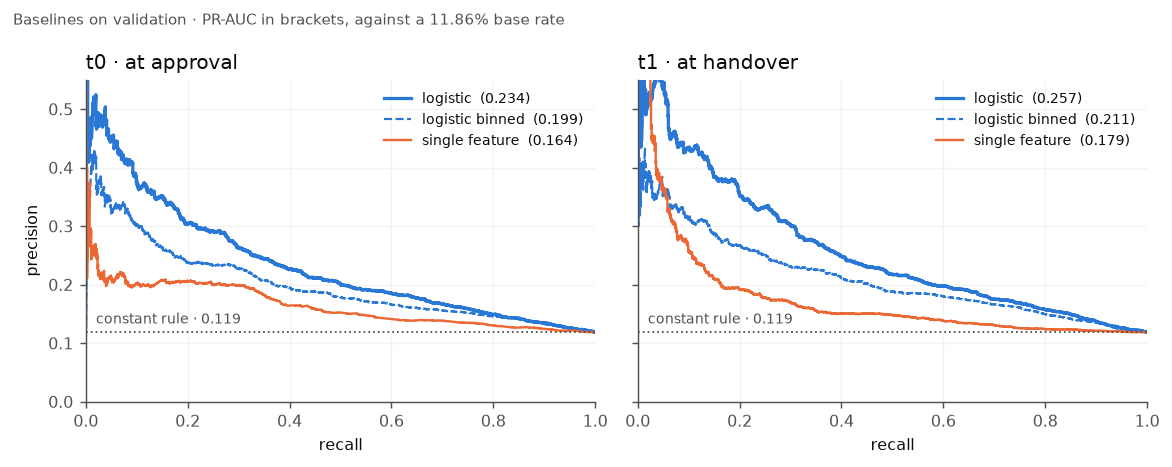

In [4]:
STYLE = {
    "logistic": (BLUE, "-", 1.8),
    "logistic binned": (BLUE, "--", 1.2),
    "single feature": (ORANGE, "-", 1.3),
}
TITLES = {"t0": "t0 · at approval", "t1": "t1 · at handover"}

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
for ax, moment in zip(axes, ("t0", "t1"), strict=True):
    frames = train.split_frames(moment, matrix)
    _, y_val = frames["val"]
    for name, (colour, style, width) in STYLE.items():
        scores = train.baseline_scores(name, moment, frames, "val")
        precision, recall, _ = precision_recall_curve(y_val, scores)
        ax.plot(
            recall,
            precision,
            color=colour,
            linestyle=style,
            linewidth=width,
            label=f"{name}  ({evaluate.pr_auc(y_val, scores):.3f})",
        )
    # The constant rule has no curve: one score for everybody collapses to a single
    # point, and joining it to the axis would draw a diagonal that reads as superb
    # precision at low recall. It belongs here as the base rate it is.
    ax.axhline(y_val.mean(), color=MUTED, linewidth=1.0, linestyle=":")
    ax.text(
        0.02, y_val.mean() + 0.015, f"constant rule · {y_val.mean():.3f}", color=MUTED, fontsize=7.5
    )
    ax.set_title(TITLES[moment], loc="left", color=INK)
    ax.set_xlabel("recall")
    ax.grid(alpha=0.5)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 0.55)
    ax.legend(frameon=False, fontsize=7.5, loc="upper right")

axes[0].set_ylabel("precision")
fig.suptitle(
    "Baselines on validation · PR-AUC in brackets, against a 11.86% base rate",
    x=0.005,
    ha="left",
    color=MUTED,
    fontsize=8.5,
)
fig.tight_layout()
fig.savefig(config.FIGURES / "baseline_pr.png", bbox_inches="tight")

## 4 · What the logistic leans on

Coefficients are not importances. The numeric features are standardised and the categorical ones
are one-hot, so a big coefficient on a category present in 300 orders moves far fewer predictions
than a small one on a feature every order has. Read the signs and the pairs, not the ranking.

The pair worth reading: `seller_prior_orders` comes out strongly positive and
`seller_prior_reviews` strongly negative, and the two are nearly the same column. The model is
using their **difference** - orders a seller has shipped whose reviews have not arrived yet,
which is recent volume it has not been judged on. A seller in a surge looks riskier. That is a
candidate feature in its own right for S4, not a defect.

In [5]:
frames = train.split_frames("t1", matrix)
X_train, y_train = frames["train"]
pipeline = train.logistic_pipeline(X_train).fit(X_train, y_train)

coefficients = pd.Series(pipeline[-1].coef_[0], index=pipeline[:-1].get_feature_names_out())
coefficients.index = coefficients.index.str.split("__").str[-1]
top = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index).head(15)
top.round(3).to_frame("coefficient")

,coefficient
product_category_livros_interesse_geral,-0.774
product_category_audio,0.708
seller_prior_orders,0.696
product_category_alimentos_bebidas,-0.694
seller_prior_reviews,-0.640
customer_state_RJ,0.470
seller_state_BA,-0.465
customer_state_AL,0.455
product_category_fashion_roupa_masculina,0.455
payment_type_boleto,-0.426


## 5 · t₀ versus t₁, measured for the first time

The comparison the project is built around. Same rows, same costs, same code: the only thing
that changes is the information the model is allowed to see.

In [6]:
scores = {}
for moment in ("t0", "t1"):
    moment_frames = train.split_frames(moment, matrix)
    scores[moment] = train.baseline_scores("logistic", moment, moment_frames, "val")
_, y_val = train.split_frames("t0", matrix)["val"]

gap, low, high = evaluate.bootstrap_difference(y_val, scores["t1"], scores["t0"])
print("logistic, PR-AUC on validation")
print(f"  t0 {evaluate.pr_auc(y_val, scores['t0']):.4f}")
print(f"  t1 {evaluate.pr_auc(y_val, scores['t1']):.4f}")
print(f"  t1 - t0 = {gap:+.4f}  [{low:+.4f}, {high:+.4f}]")

logistic, PR-AUC on validation
  t0 0.2342
  t1 0.2572
  t1 - t0 = +0.0230  [+0.0132, +0.0316]


## What LightGBM has to beat

| | t₀ | t₁ |
|---|---|---|
| Floor (base rate) | 0.1186 | 0.1186 |
| Best single feature | 0.1645 | 0.1788 |
| **Logistic** | **0.2342** | **0.2572** |

Those two bold numbers are the bar. A tree that lands on them adds complexity for nothing, and
the honest thing is to say so.

What S3 knows going into B4:

- The signal survives being treated linearly. Bending the features the crude way made things
  worse, so **interactions** are the leading hypothesis for anything LightGBM adds - though a
  smoother treatment of curvature was never tried, so the two are not fully separated.
- The handover is worth +0.023 PR-AUC [+0.013, +0.032] over what is known at approval - real,
  and smaller than the univariate AUCs of S2 might have suggested.
- Seller history matters through a difference the logistic found on its own, which is a hint
  about what a tree will find in the same columns.